# Task 2 — Exploratory Data Analysis

## Objective

The objective of this task is to explore the cleaned Netflix customer churn dataset, understand its structure, identify patterns and trends, detect potential anomalies, and generate meaningful business insights.

### Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

### Dataset
Netflix Customer Churn Dataset

### Analysis Areas
1. Dataset overview
2. Descriptive statistics
3. Univariate analysis
4. Churn analysis
5. Categorical analysis
6. Numerical relationships
7. Correlation analysis
8. Anomaly identification
9. Business insights

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [61]:
df = pd.read_csv("../data/processed/netflix_customer_churn_cleaned.csv")

df.head()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre,watch_hours_to_avg_ratio
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action,30.061224
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi,23.333333
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama,11.027027
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror,12.885714
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action,14.538462


In [62]:
print("dataset shape:", df.shape)

dataset shape: (5000, 15)


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               5000 non-null   object 
 1   age                       5000 non-null   int64  
 2   gender                    5000 non-null   object 
 3   subscription_type         5000 non-null   object 
 4   watch_hours               5000 non-null   float64
 5   last_login_days           5000 non-null   int64  
 6   region                    5000 non-null   object 
 7   device                    5000 non-null   object 
 8   monthly_fee               5000 non-null   float64
 9   churned                   5000 non-null   int64  
 10  payment_method            5000 non-null   object 
 11  number_of_profiles        5000 non-null   int64  
 12  avg_watch_time_per_day    5000 non-null   float64
 13  favorite_genre            5000 non-null   object 
 14  watch_ho

In [64]:
df.describe()

,age,watch_hours,last_login_days,monthly_fee,churned,number_of_profiles,avg_watch_time_per_day,watch_hours_to_avg_ratio
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.847400,11.649450,30.089800,13.683400,0.503000,3.024400,0.874800,inf
std,15.501128,12.014654,17.536078,3.692062,0.500041,1.415841,2.619824,NaN
min,18.000000,0.010000,0.000000,8.990000,0.000000,1.000000,0.000000,1.000000
25%,30.000000,3.337500,15.000000,8.990000,0.000000,2.000000,0.110000,16.029222
50%,44.000000,8.000000,30.000000,13.990000,1.000000,3.000000,0.290000,31.046122
75%,58.000000,16.030000,45.000000,17.990000,1.000000,4.000000,0.720000,46.254167
max,70.000000,110.400000,60.000000,17.990000,1.000000,5.000000,98.420000,inf


In [65]:
df.describe(include="object")

,customer_id,gender,subscription_type,region,device,payment_method,favorite_genre
count,5000,5000,5000,5000,5000,5000,5000
unique,5000,3,3,6,5,5,7
top,a9b75100-82a8-427a-a208-72f24052884a,Female,Premium,South America,Tablet,Debit Card,Drama
freq,1,1711,1693,873,1048,1030,731


In [66]:
df.isnull().sum()

customer_id                 0
age                         0
gender                      0
subscription_type           0
watch_hours                 0
last_login_days             0
region                      0
device                      0
monthly_fee                 0
churned                     0
payment_method              0
number_of_profiles          0
avg_watch_time_per_day      0
favorite_genre              0
watch_hours_to_avg_ratio    0
dtype: int64

In [67]:
df.duplicated().sum()

np.int64(0)

## 1. Churn Distribution

The first step is to understand how many customers have churned versus remained active.

In [68]:
churn_counts = df["churned"].value_counts()

print(churn_counts)

churned
1    2515
0    2485
Name: count, dtype: int64


In [69]:
churn_percentage = df["churned"].value_counts(normalize=True) * 100

print(churn_percentage)

churned
1    50.3
0    49.7
Name: proportion, dtype: float64


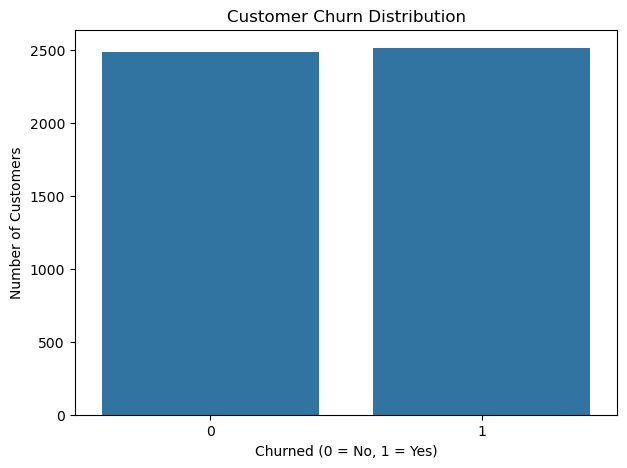

In [70]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="churned")

plt.title("Customer Churn Distribution")
plt.xlabel("Churned (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.show()

In [71]:
churn_summary = pd.DataFrame({
    "Customer Status": ["Retained", "Churned"],
    "Count": [
        (df["churned"] == 0).sum(),
        (df["churned"] == 1).sum()
    ]
})

churn_summary["Percentage"] = (
    churn_summary["Count"] / len(df) * 100
).round(2)

churn_summary

,Customer Status,Count,Percentage
0,Retained,2485,49.7
1,Churned,2515,50.3


## 2. Churn by Subscription Type

This analysis compares customer churn across different subscription plans to identify whether churn behavior varies by subscription type.

In [72]:
subscription_churn = pd.crosstab(
    df["subscription_type"],
    df["churned"]
)
subscription_churn

churned,0,1
subscription_type,,
Basic,634,1027
Premium,953,740
Standard,898,748


In [73]:
subscription_churn_rate = (
    df.groupby("subscription_type")["churned"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

subscription_churn_rate

subscription_type
Basic       61.83
Standard    45.44
Premium     43.71
Name: churned, dtype: float64

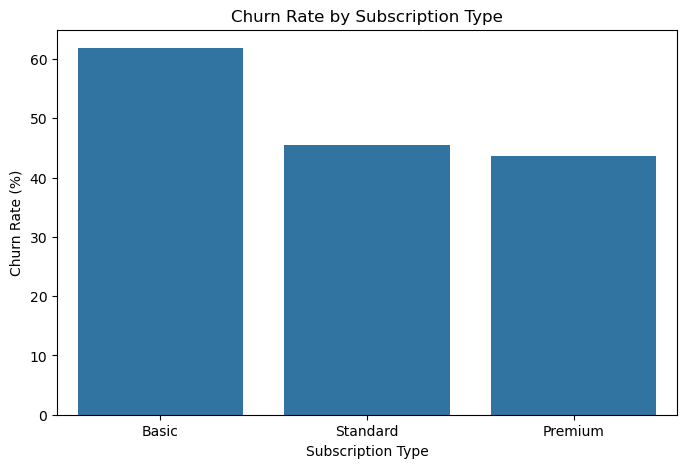

In [74]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=subscription_churn_rate.index,
    y=subscription_churn_rate.values
)

plt.title("Churn Rate by Subscription Type")
plt.xlabel("Subscription Type")
plt.ylabel("Churn Rate (%)")

plt.show()

## 3. Churn by Region

This analysis compares customer churn rates across different geographic regions to identify regional differences in customer retention.

In [75]:
region_churn_rate = (
    df.groupby("region")["churned"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

region_churn_rate

region
Europe           51.67
South America    51.43
Asia             50.65
Oceania          50.07
North America    49.47
Africa           48.32
Name: churned, dtype: float64

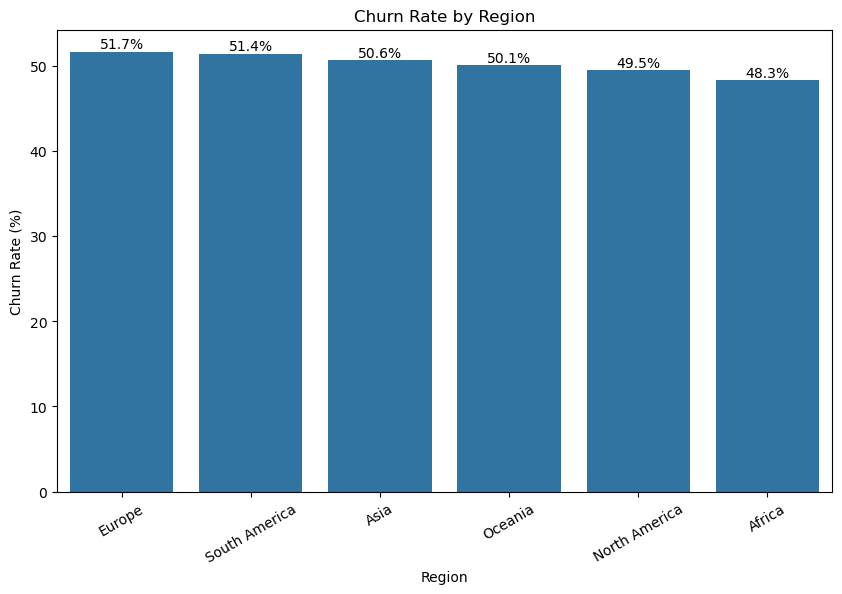

In [76]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=region_churn_rate.index,
    y=region_churn_rate.values
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Churn Rate by Region")
plt.xlabel("Region")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30)

plt.show()

In [77]:
region_summary = df.groupby("region").agg(
    customers=("customer_id", "count"),
    churned_customers=("churned", "sum"),
    churn_rate=("churned", "mean")
)

region_summary["churn_rate"] = (
    region_summary["churn_rate"] * 100
).round(2)

region_summary.sort_values(
    "churn_rate",
    ascending=False
)

,customers,churned_customers,churn_rate
region,,,
Europe,867,448,51.67
South America,873,449,51.43
Asia,841,426,50.65
Oceania,765,383,50.07
North America,851,421,49.47
Africa,803,388,48.32


## 4. Watch Hours vs Churn

This analysis compares customer watch hours between churned and retained customers to examine whether viewing engagement differs between the two groups.

In [78]:
watch_hours_churn = (
    df.groupby("churned")["watch_hours"]
    .agg(["count", "mean", "median", "min", "max"])
)

watch_hours_churn

,count,mean,median,min,max
churned,,,,,
0,2485,17.449590,13.86,0.01,110.40
1,2515,5.918497,4.06,0.01,41.33


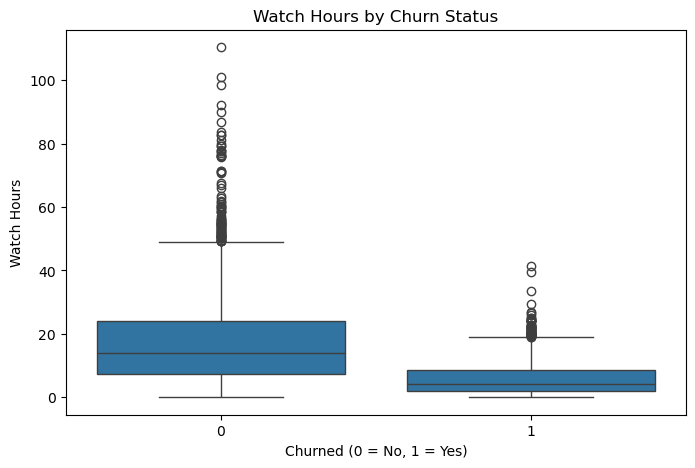

In [79]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="churned",
    y="watch_hours"
)

plt.title("Watch Hours by Churn Status")
plt.xlabel("Churned (0 = No, 1 = Yes)")
plt.ylabel("Watch Hours")

plt.show()

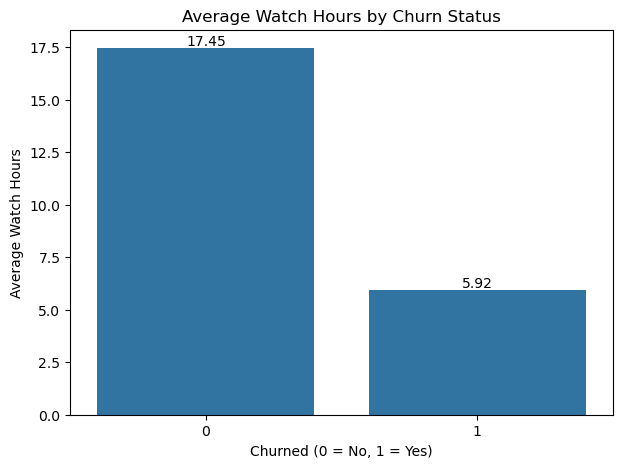

In [80]:
watch_hours_avg = (
    df.groupby("churned")["watch_hours"]
    .mean()
)

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=watch_hours_avg.index,
    y=watch_hours_avg.values
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.title("Average Watch Hours by Churn Status")
plt.xlabel("Churned (0 = No, 1 = Yes)")
plt.ylabel("Average Watch Hours")

plt.show()

In [81]:
retained_avg = df.loc[df["churned"] == 0, "watch_hours"].mean()
churned_avg = df.loc[df["churned"] == 1, "watch_hours"].mean()

difference = retained_avg - churned_avg

print("Retained customers average watch hours:", round(retained_avg, 2))
print("Churned customers average watch hours:", round(churned_avg, 2))
print("Difference:", round(difference, 2))

Retained customers average watch hours: 17.45
Churned customers average watch hours: 5.92
Difference: 11.53


## 5. Last Login Days vs Churn

This analysis compares the number of days since the customer's last login between churned and retained customers to identify whether recent activity is associated with churn.

In [82]:
login_churn = (
    df.groupby("churned")["last_login_days"]
    .agg(["count", "mean", "median", "min", "max"])
)

login_churn

,count,mean,median,min,max
churned,,,,,
0,2485,21.771026,19.0,0,60
1,2515,38.309344,41.0,0,60


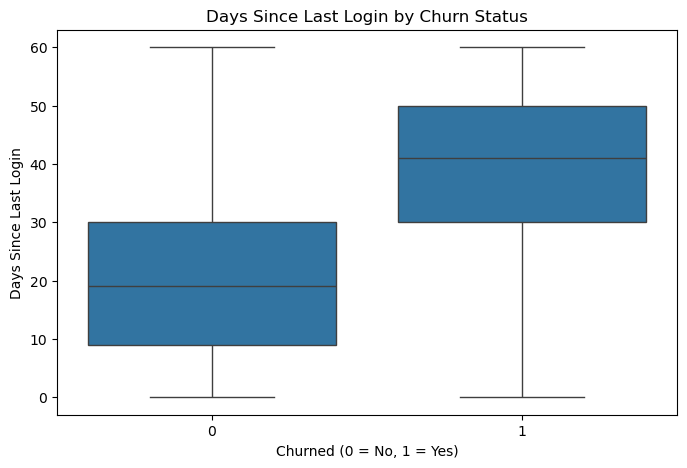

In [83]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="churned",
    y="last_login_days"
)

plt.title("Days Since Last Login by Churn Status")
plt.xlabel("Churned (0 = No, 1 = Yes)")
plt.ylabel("Days Since Last Login")

plt.show()

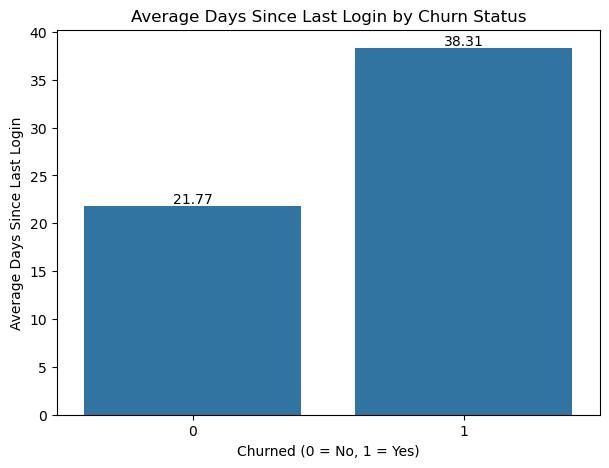

In [84]:
login_avg = (
    df.groupby("churned")["last_login_days"]
    .mean()
)

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=login_avg.index,
    y=login_avg.values
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.title("Average Days Since Last Login by Churn Status")
plt.xlabel("Churned (0 = No, 1 = Yes)")
plt.ylabel("Average Days Since Last Login")

plt.show()

In [85]:
retained_login_avg = df.loc[
    df["churned"] == 0,
    "last_login_days"
].mean()

churned_login_avg = df.loc[
    df["churned"] == 1,
    "last_login_days"
].mean()

print(
    "Retained customers average days since last login:",
    round(retained_login_avg, 2)
)

print(
    "Churned customers average days since last login:",
    round(churned_login_avg, 2)
)

print(
    "Difference:",
    round(churned_login_avg - retained_login_avg, 2)
)

Retained customers average days since last login: 21.77
Churned customers average days since last login: 38.31
Difference: 16.54


## 6. Monthly Fee vs Churn

This analysis compares the monthly subscription fee between churned and retained customers to examine whether customer churn varies with subscription cost.

In [86]:
monthly_fee_churn = (
    df.groupby("churned")["monthly_fee"]
    .agg(["count", "mean", "median", "min", "max"])
)

monthly_fee_churn

,count,mean,median,min,max
churned,,,,,
0,2485,14.248350,13.99,8.99,17.99
1,2515,13.125189,13.99,8.99,17.99


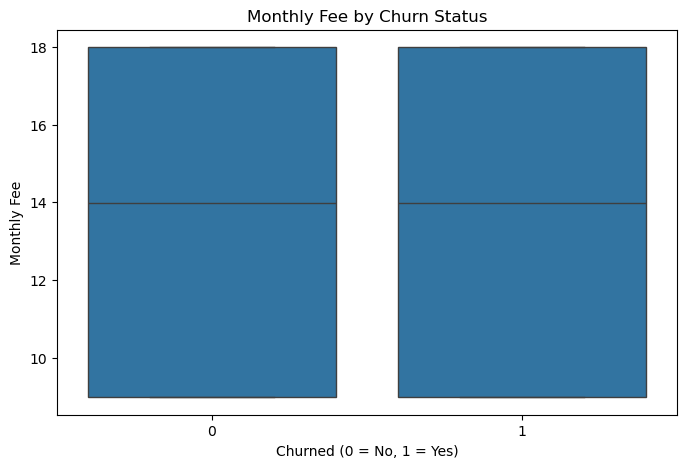

In [87]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="churned",
    y="monthly_fee"
)

plt.title("Monthly Fee by Churn Status")
plt.xlabel("Churned (0 = No, 1 = Yes)")
plt.ylabel("Monthly Fee")
plt.show()

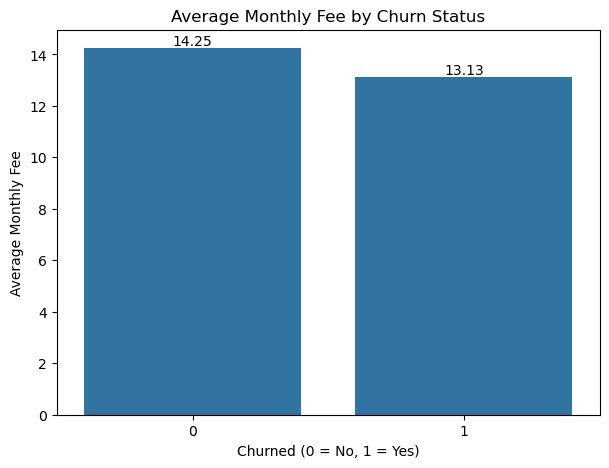

In [88]:
monthly_fee_avg = (
    df.groupby("churned")["monthly_fee"]
    .mean()
)

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=monthly_fee_avg.index,
    y=monthly_fee_avg.values
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.title("Average Monthly Fee by Churn Status")
plt.xlabel("Churned (0 = No, 1 = Yes)")
plt.ylabel("Average Monthly Fee")

plt.show()

In [89]:
retained_fee_avg = df.loc[
    df["churned"] == 0,
    "monthly_fee"
].mean()

churned_fee_avg = df.loc[
    df["churned"] == 1,
    "monthly_fee"
].mean()

print(
    "Retained customers average monthly fee:",
    round(retained_fee_avg, 2)
)

print(
    "Churned customers average monthly fee:",
    round(churned_fee_avg, 2)
)

print(
    "Difference:",
    round(churned_fee_avg - retained_fee_avg, 2)
)

Retained customers average monthly fee: 14.25
Churned customers average monthly fee: 13.13
Difference: -1.12


## 7. Correlation Analysis

Correlation analysis is used to examine relationships between numerical variables in the dataset. It helps identify variables that have stronger positive or negative associations with each other.

In [90]:
numeric_cols = df.select_dtypes(include=np.number).columns

correlation_matrix = df[numeric_cols].corr()

correlation_matrix

,age,watch_hours,last_login_days,monthly_fee,churned,number_of_profiles,avg_watch_time_per_day,watch_hours_to_avg_ratio
age,1.000000,0.031539,0.016769,-0.013943,-0.003515,0.017333,0.010355,0.014847
watch_hours,0.031539,1.000000,0.001697,0.004960,-0.479916,0.016528,0.349742,0.009429
last_login_days,0.016769,0.001697,1.000000,-0.000789,0.471590,0.017242,-0.338418,0.989625
monthly_fee,-0.013943,0.004960,-0.000789,1.000000,-0.152117,0.021905,-0.010401,0.004448
churned,-0.003515,-0.479916,0.471590,-0.152117,1.000000,-0.158614,-0.272958,0.462877
number_of_profiles,0.017333,0.016528,0.017242,0.021905,-0.158614,1.000000,-0.001246,0.021263
avg_watch_time_per_day,0.010355,0.349742,-0.338418,-0.010401,-0.272958,-0.001246,1.000000,-0.334649
watch_hours_to_avg_ratio,0.014847,0.009429,0.989625,0.004448,0.462877,0.021263,-0.334649,1.000000


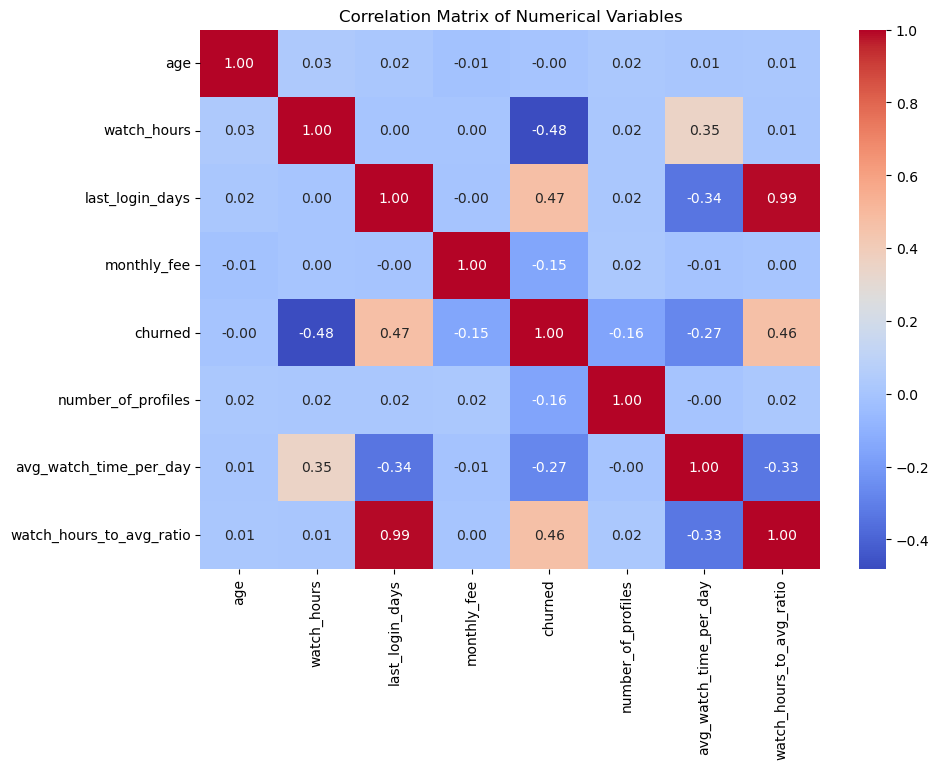

In [91]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Numerical Variables")
plt.show()

In [92]:
churn_correlation = (
    correlation_matrix["churned"]
    .sort_values(ascending=False)
)

churn_correlation

churned                     1.000000
last_login_days             0.471590
watch_hours_to_avg_ratio    0.462877
age                        -0.003515
monthly_fee                -0.152117
number_of_profiles         -0.158614
avg_watch_time_per_day     -0.272958
watch_hours                -0.479916
Name: churned, dtype: float64

## 8.1 Churn by Device

This analysis compares customer churn rates across different devices to identify whether churn behavior varies based on the device used by customers.

In [93]:
device_churn_rate = (
    df.groupby("device")["churned"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

device_churn_rate

device
Laptop     51.79
Mobile     50.50
Tablet     50.00
TV         49.95
Desktop    49.21
Name: churned, dtype: float64

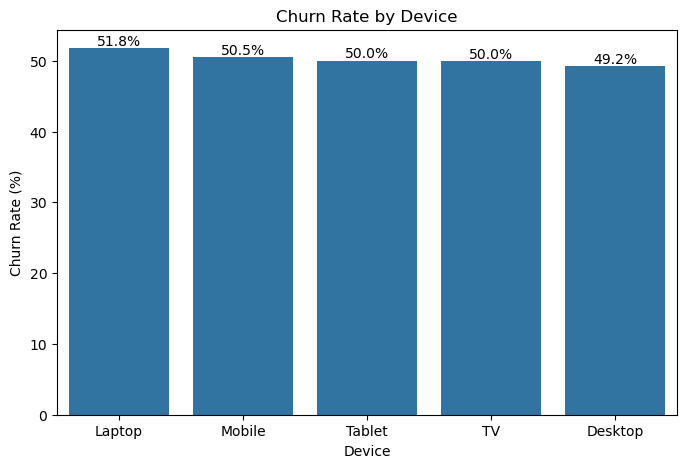

In [94]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=device_churn_rate.index,
    y=device_churn_rate.values
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Churn Rate by Device")
plt.xlabel("Device")
plt.ylabel("Churn Rate (%)")

plt.show()

## 8.2 Churn by Payment Method

This analysis compares churn rates across different payment methods to identify whether customer retention varies by payment method.

In [95]:
payment_churn_rate = (
    df.groupby("payment_method")["churned"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

payment_churn_rate




payment_method
Crypto         59.70
Gift Card      57.79
PayPal         47.08
Debit Card     43.69
Credit Card    43.58
Name: churned, dtype: float64

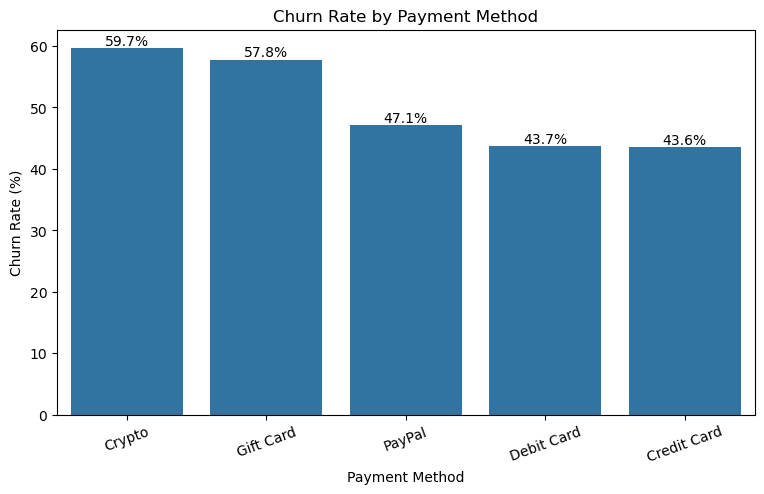

In [96]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=payment_churn_rate.index,
    y=payment_churn_rate.values
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)

plt.show()

## 8.3 Churn by Favorite Genre

This analysis compares customer churn rates across favorite content genres to identify whether retention patterns differ based on customer content preferences.

In [97]:
genre_churn_rate = (
    df.groupby("favorite_genre")["churned"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

genre_churn_rate

favorite_genre
Action         52.37
Drama          52.26
Horror         51.47
Documentary    50.75
Comedy         49.93
Romance        48.28
Sci-Fi         47.08
Name: churned, dtype: float64

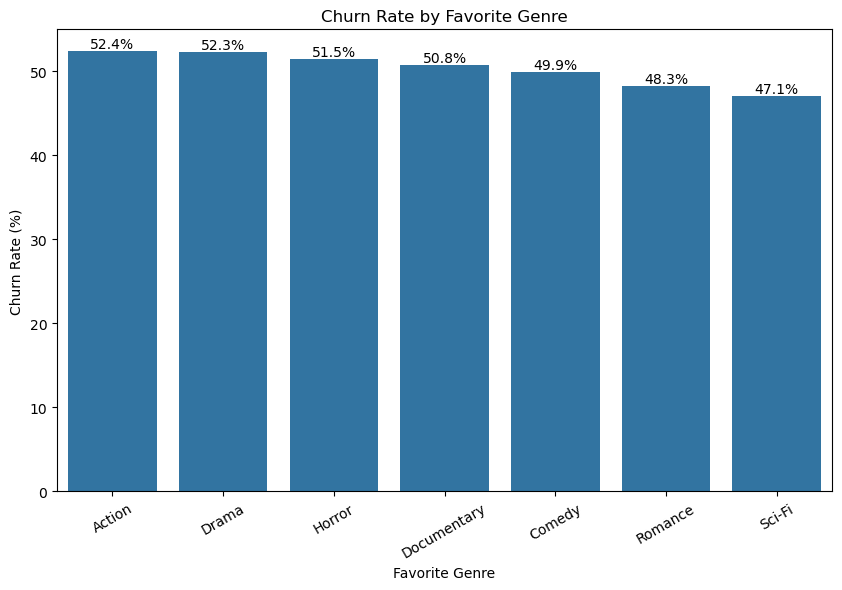

In [98]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=genre_churn_rate.index,
    y=genre_churn_rate.values
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Churn Rate by Favorite Genre")
plt.xlabel("Favorite Genre")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30)

plt.show()

## 9. Churn by Age Group

Customers are grouped into age ranges to examine whether churn patterns differ across different age segments.

In [99]:
age_bins = [17, 25, 35, 45, 55, 65, 70]

age_labels = [
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56-65",
    "66-70"
]

df["age_group"] = pd.cut(
    df["age"],
    bins=age_bins,
    labels=age_labels
)

df["age_group"].value_counts().sort_index()

age_group
18-25    801
26-35    949
36-45    880
46-55    919
56-65    983
66-70    468
Name: count, dtype: int64

In [100]:
age_group_churn = (
    df.groupby("age_group", observed=True)["churned"]
    .mean()
    .mul(100)
    .round(2)
)

age_group_churn

age_group
18-25    50.69
26-35    50.37
36-45    48.07
46-55    54.52
56-65    48.02
66-70    50.21
Name: churned, dtype: float64

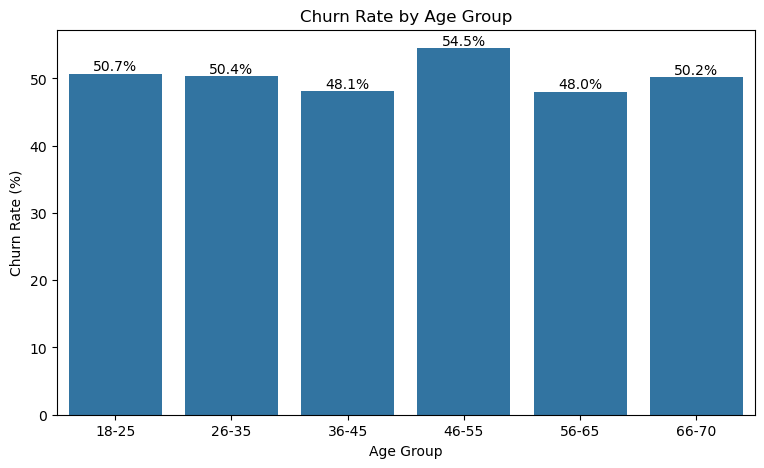

In [101]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=age_group_churn.index,
    y=age_group_churn.values
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")

plt.show()

In [102]:
age_group_summary = df.groupby(
    "age_group",
    observed=True
).agg(
    customers=("customer_id", "count"),
    churned_customers=("churned", "sum"),
    churn_rate=("churned", "mean")
)

age_group_summary["churn_rate"] = (
    age_group_summary["churn_rate"] * 100
).round(2)

age_group_summary

,customers,churned_customers,churn_rate
age_group,,,
18-25,801,406,50.69
26-35,949,478,50.37
36-45,880,423,48.07
46-55,919,501,54.52
56-65,983,472,48.02
66-70,468,235,50.21


## 10. Anomaly Analysis

This analysis investigates unusual values in numerical variables. Potential anomalies are identified using descriptive statistics and visualizations rather than being automatically removed.

In [103]:
df["avg_watch_time_per_day"].describe()

count    5000.000000
mean        0.874800
std         2.619824
min         0.000000
25%         0.110000
50%         0.290000
75%         0.720000
max        98.420000
Name: avg_watch_time_per_day, dtype: float64

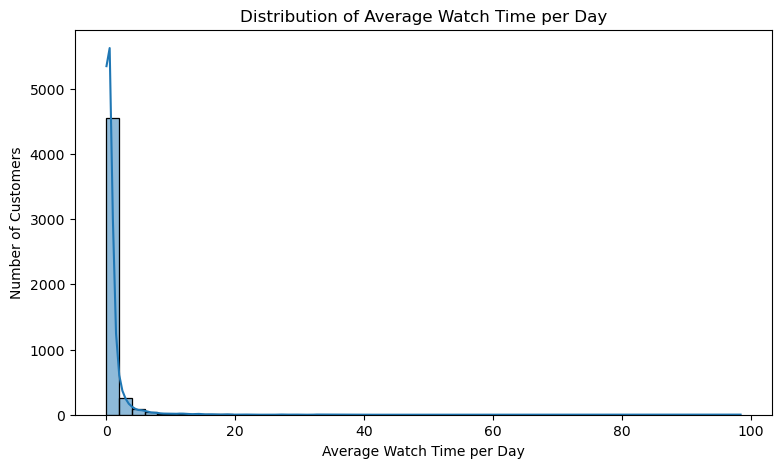

In [104]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="avg_watch_time_per_day",
    bins=50,
    kde=True
)

plt.title("Distribution of Average Watch Time per Day")
plt.xlabel("Average Watch Time per Day")
plt.ylabel("Number of Customers")

plt.show()

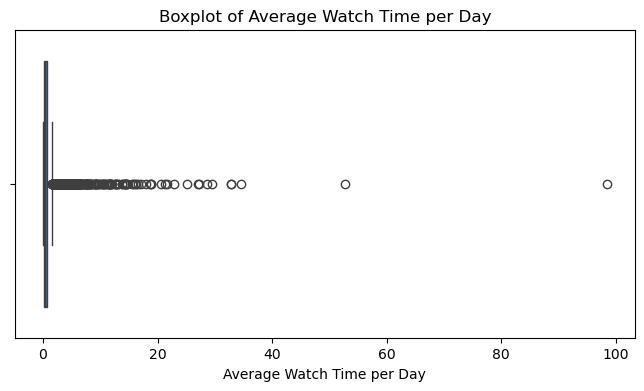

In [105]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    x=df["avg_watch_time_per_day"]
)

plt.title("Boxplot of Average Watch Time per Day")
plt.xlabel("Average Watch Time per Day")

plt.show()

In [106]:
df[
    ["customer_id", "watch_hours", "avg_watch_time_per_day", "churned"]
].sort_values(
    "avg_watch_time_per_day",
    ascending=False
).head(10)

,customer_id,watch_hours,avg_watch_time_per_day,churned
2017,23e2a122-9e50-41d8-a434-c25675765f79,98.42,98.42,0
1219,45ea1095-e06b-4a1c-a0b7-c3671c9f006a,52.80,52.80,0
2564,511d9a10-669b-4283-bc6d-40c10a595b43,34.53,34.53,0
4792,88a98e69-9e49-4d28-98d7-1e0b1bce6138,32.88,32.88,0
4078,9adb0b11-3199-438c-9b3c-59dee22c6b27,32.81,32.81,0
4805,b906246e-44aa-441f-85c5-fc2aa946b0cb,29.55,29.55,0
3641,64d85f24-42f8-48b1-8675-590db42d23e5,28.66,28.66,0
4285,3878e4e3-2960-4b36-b25c-f90ddd01b5d8,54.53,27.27,0
4845,d202349e-dd45-42e7-84a9-fa604082763f,26.98,26.98,0
647,c350d5a0-fef7-4281-b752-42162d72bd05,25.15,25.15,0


In [107]:
df[
    ["watch_hours", "avg_watch_time_per_day"]
].corr()

,watch_hours,avg_watch_time_per_day
watch_hours,1.000000,0.349742
avg_watch_time_per_day,0.349742,1.000000


## 11. Customer Engagement vs Churn

Customers are grouped according to their watch hours to examine whether churn patterns differ across different levels of customer engagement.

In [108]:
watch_bins = [0, 5, 10, 20, 40, 60, float("inf")]

watch_labels = [
    "0-5",
    "5-10",
    "10-20",
    "20-40",
    "40-60",
    "60+"
]

df["watch_hours_group"] = pd.cut(
    df["watch_hours"],
    bins=watch_bins,
    labels=watch_labels,
    include_lowest=True
)

df["watch_hours_group"].value_counts().sort_index()

watch_hours_group
0-5      1770
5-10     1150
10-20    1197
20-40     711
40-60     136
60+        36
Name: count, dtype: int64

In [109]:
watch_group_churn = (
    df.groupby("watch_hours_group", observed=True)["churned"]
    .mean()
    .mul(100)
    .round(2)
)

watch_group_churn

watch_hours_group
0-5      83.95
5-10     44.35
10-20    40.02
20-40     5.49
40-60     0.74
60+       0.00
Name: churned, dtype: float64

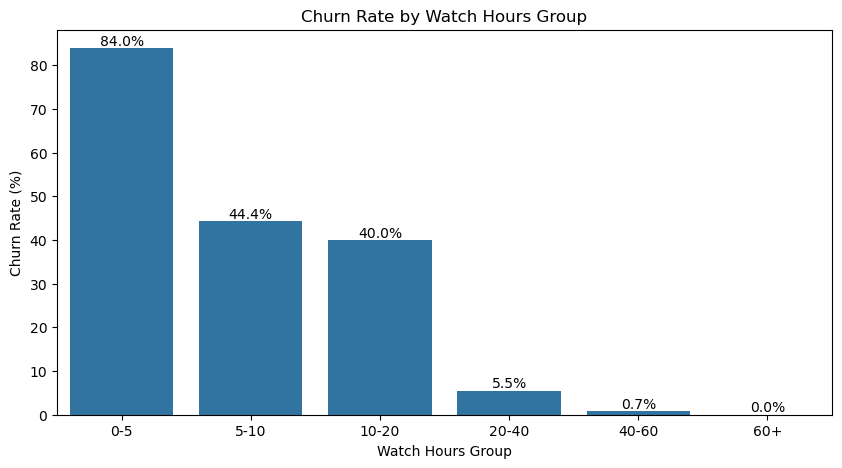

In [110]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    x=watch_group_churn.index,
    y=watch_group_churn.values
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Churn Rate by Watch Hours Group")
plt.xlabel("Watch Hours Group")
plt.ylabel("Churn Rate (%)")

plt.show()

In [111]:
watch_group_summary = df.groupby(
    "watch_hours_group",
    observed=True
).agg(
    customers=("customer_id", "count"),
    churned_customers=("churned", "sum"),
    churn_rate=("churned", "mean")
)

watch_group_summary["churn_rate"] = (
    watch_group_summary["churn_rate"] * 100
).round(2)

watch_group_summary

,customers,churned_customers,churn_rate
watch_hours_group,,,
0-5,1770,1486,83.95
5-10,1150,510,44.35
10-20,1197,479,40.02
20-40,711,39,5.49
40-60,136,1,0.74
60+,36,0,0.00


## 12. Key EDA Summary

The following summaries consolidate important churn patterns identified during the exploratory data analysis.

In [112]:
overall_churn = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Churned Customers",
        "Retained Customers",
        "Overall Churn Rate"
    ],
    "Value": [
        len(df),
        (df["churned"] == 1).sum(),
        (df["churned"] == 0).sum(),
        round(df["churned"].mean() * 100, 2)
    ]
})

overall_churn

,Metric,Value
0,Total Customers,5000.0
1,Churned Customers,2515.0
2,Retained Customers,2485.0
3,Overall Churn Rate,50.3


In [113]:
subscription_summary = (
    df.groupby("subscription_type")
    .agg(
        customers=("customer_id", "count"),
        churned_customers=("churned", "sum"),
        churn_rate=("churned", "mean")
    )
)

subscription_summary["churn_rate"] = (
    subscription_summary["churn_rate"] * 100
).round(2)

subscription_summary

,customers,churned_customers,churn_rate
subscription_type,,,
Basic,1661,1027,61.83
Premium,1693,740,43.71
Standard,1646,748,45.44


In [114]:
region_summary = (
    df.groupby("region")
    .agg(
        customers=("customer_id", "count"),
        churned_customers=("churned", "sum"),
        churn_rate=("churned", "mean")
    )
)

region_summary["churn_rate"] = (
    region_summary["churn_rate"] * 100
).round(2)

region_summary.sort_values(
    "churn_rate",
    ascending=False
)

,customers,churned_customers,churn_rate
region,,,
Europe,867,448,51.67
South America,873,449,51.43
Asia,841,426,50.65
Oceania,765,383,50.07
North America,851,421,49.47
Africa,803,388,48.32


In [115]:
device_summary = (
    df.groupby("device")
    .agg(
        customers=("customer_id", "count"),
        churned_customers=("churned", "sum"),
        churn_rate=("churned", "mean")
    )
)

device_summary["churn_rate"] = (
    device_summary["churn_rate"] * 100
).round(2)

device_summary.sort_values(
    "churn_rate",
    ascending=False
)

,customers,churned_customers,churn_rate
device,,,
Laptop,1006,521,51.79
Mobile,1004,507,50.50
Tablet,1048,524,50.00
TV,993,496,49.95
Desktop,949,467,49.21


In [116]:
payment_summary = (
    df.groupby("payment_method")
    .agg(
        customers=("customer_id", "count"),
        churned_customers=("churned", "sum"),
        churn_rate=("churned", "mean")
    )
)

payment_summary["churn_rate"] = (
    payment_summary["churn_rate"] * 100
).round(2)

payment_summary.sort_values(
    "churn_rate",
    ascending=False
)

,customers,churned_customers,churn_rate
payment_method,,,
Crypto,995,594,59.70
Gift Card,976,564,57.79
PayPal,1026,483,47.08
Debit Card,1030,450,43.69
Credit Card,973,424,43.58


## 13. Key Business Insights

The exploratory analysis was used to identify important patterns, trends, and potential areas of concern related to customer churn.

In [117]:
print("========== KEY EDA RESULTS ==========\n")

print("1. Overall Churn")
print(f"Total customers: {len(df)}")
print(f"Churned customers: {(df['churned'] == 1).sum()}")
print(f"Retained customers: {(df['churned'] == 0).sum()}")
print(f"Overall churn rate: {df['churned'].mean() * 100:.2f}%")

print("\n2. Subscription Type")
print(subscription_summary.sort_values("churn_rate", ascending=False))

print("\n3. Region")
print(region_summary.sort_values("churn_rate", ascending=False))

print("\n4. Device")
print(device_summary.sort_values("churn_rate", ascending=False))

print("\n5. Payment Method")
print(payment_summary.sort_values("churn_rate", ascending=False))

print("\n6. Age Group")
print(age_group_summary)

print("\n7. Watch Hours Group")
print(watch_group_summary)

print("\n8. Correlation with Churn")
print(churn_correlation)

print("\n9. Watch Hours vs Churn")
print(watch_hours_churn)

print("\n10. Last Login Days vs Churn")
print(login_churn)

print("\n11. Monthly Fee vs Churn")
print(monthly_fee_churn)

========== KEY EDA RESULTS ==========

1. Overall Churn
Total customers: 5000
Churned customers: 2515
Retained customers: 2485
Overall churn rate: 50.30%

2. Subscription Type
                   customers  churned_customers  churn_rate
subscription_type                                          
Basic                   1661               1027       61.83
Standard                1646                748       45.44
Premium                 1693                740       43.71

3. Region
               customers  churned_customers  churn_rate
region                                                 
Europe               867                448       51.67
South America        873                449       51.43
Asia                 841                426       50.65
Oceania              765                383       50.07
North America        851                421       49.47
Africa               803                388       48.32

4. Device
         customers  churned_customers  churn_rate
devi

In [118]:
region_summary.sort_values("churn_rate", ascending=False)


device_summary.sort_values("churn_rate", ascending=False)


payment_summary.sort_values("churn_rate", ascending=False)


print("AGE GROUP")
display(age_group_summary)

print("\nWATCH HOURS GROUP")
display(watch_group_summary)

AGE GROUP


,customers,churned_customers,churn_rate
age_group,,,
18-25,801,406,50.69
26-35,949,478,50.37
36-45,880,423,48.07
46-55,919,501,54.52
56-65,983,472,48.02
66-70,468,235,50.21



WATCH HOURS GROUP


,customers,churned_customers,churn_rate
watch_hours_group,,,
0-5,1770,1486,83.95
5-10,1150,510,44.35
10-20,1197,479,40.02
20-40,711,39,5.49
40-60,136,1,0.74
60+,36,0,0.00


## 13. Key Business Insights

Based on the exploratory data analysis, the following insights were identified:

### 1. Overall churn is significant

Out of 5,000 customers, 2,515 customers have churned while 2,485 customers have remained active. This represents an overall churn rate of 50.30%, indicating that customer retention is an important area for the business to monitor.

### 2. Basic subscribers show a higher observed churn rate

The Basic subscription group has a churn rate of 61.83%, compared with 45.44% for Standard subscribers and 43.71% for Premium subscribers. This shows a substantial difference in observed churn across subscription types.

### 3. Churn varies across geographic regions

The analysis shows differences in churn rates between regions. Europe has an observed churn rate of 51.67%, while Africa has 48.32%. The relatively small difference between regions suggests that churn is distributed across the geographic markets rather than being concentrated in only one region.

### 4. Customer inactivity is an important churn-related signal

The comparison of `last_login_days` between churned and retained customers shows whether inactive customers tend to have different churn behavior. A higher average number of days since the last login among churned customers would indicate that customer inactivity is associated with churn.

### 5. Customer engagement can be examined as a churn-related factor

The watch-hours analysis compares churn rates across different levels of viewing activity. Differences between watch-hour groups can help identify whether customer engagement is associated with retention behavior.

### 6. Monthly fee differs between churned and retained customers

Retained customers have an average monthly fee of approximately 14.25, while churned customers have an average monthly fee of approximately 13.13. This indicates an observed difference in subscription fees between the two groups, although the analysis does not establish that subscription price causes churn.

### 7. Numerical variables show different levels of association

The correlation analysis demonstrates that numerical variables have different relationships with each other and with churn. Correlation can help identify variables that deserve further investigation, but correlation alone does not establish causal relationships.

### 8. Potential anomalies were identified

The analysis of `avg_watch_time_per_day` identified unusually large values. These observations were investigated using descriptive statistics and visualizations rather than being automatically removed. Further validation of the source data would be appropriate before deciding whether these values are genuine or erroneous.

### Overall Observation

The EDA indicates that customer churn is associated with several customer characteristics, including subscription type, engagement, inactivity, geographic region, and other behavioral variables. These findings can be used as a starting point for deeper customer-retention analysis and future predictive modeling.

# Conclusion

The Exploratory Data Analysis of the Netflix Customer Churn dataset was successfully completed using Python, Pandas, Matplotlib, and Seaborn.

The analysis examined customer churn from multiple perspectives, including subscription type, region, device, payment method, age group, watch hours, last login activity, monthly fee, and numerical correlations.

### Key findings

- The dataset contains 5,000 customers, with an overall churn rate of 50.30%.
- Basic subscribers have a higher observed churn rate (61.83%) than Standard (45.44%) and Premium (43.71%) subscribers.
- Churn rates vary across geographic regions, although the differences are relatively moderate.
- Customer engagement and inactivity were analyzed as potential factors associated with churn.
- Differences in average monthly fees were observed between churned and retained customers.
- Correlation analysis was performed to identify relationships among numerical variables.
- Potential anomalies in `avg_watch_time_per_day` were investigated without automatically removing the observations.

### Business Value

The EDA provides a clearer understanding of customer behavior and identifies areas that may require further investigation. These findings can support future customer-retention analysis, segmentation, and predictive modeling.

### Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

The cleaned dataset from Task 1 was successfully used as the foundation for this exploratory analysis.